In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram

In [3]:
# Load the full dataset
df = pd.read_json("../data/supervise_ready_df.json", lines=True)

# Quick preview
df.shape
df.head(3)
print(df.columns)

Index(['id', 'text', 'type', 'source', 'imdb_title', 'imdb_year',
       'imdb_genres', 'imdb_plot', 'book_title', 'book_authors',
       'book_description', 'book_publishedDate', 'skip_reason', 'imdb_error',
       'inferred_media_type', 'suspect_format', 'book_year',
       'data_quality_flag', 'myth_keyword_hits', 'myth_hit_count',
       'has_myth_hit', 'tropes_matched', 'myth_trope_hits',
       'has_myth_trope_hit', 'myth_influenced', 'myth_influence_type',
       'max_trope_similarity', 'combined_text', 'sentence_matched_tropes',
       'sentence_myth_trope_hits', 'has_sentence_myth_trope_hit',
       'has_lexical_match', 'has_semantic_match', 'tropes_lexical_match',
       'tropes_semantic_match', 'myth_influence_mode'],
      dtype='object')


In [5]:
# Convert NaNs to empty lists if needed
df['tropes_semantic_match'] = df['tropes_semantic_match'].apply(lambda x: x if isinstance(x, list) else [])

# Create binary matrix
mlb = MultiLabelBinarizer()
trope_matrix = mlb.fit_transform(df['tropes_semantic_match'])

# Convert to DataFrame
df_tropes = pd.DataFrame(trope_matrix, columns=mlb.classes_, index=df.index)

# Sanity check
df_tropes.head()

,AnimalMotifs,AntiHero,BeastMan,BigBad,BornOfMagic,DarkestHour,DealWithTheDevil,DragonsAreDivine,ElementalEmbodiment,FateWorseThanDeath,...,Reincarnation,Satan,ShapeshifterShowdown,SkyGod,SpiritAdvisor,TheChosenOne,TheTrickster,Trickster God,WarGod,WhiteMage
0,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
1,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
2,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
3,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,1,0


In [7]:
#start with k-means clustering
# Try a range of cluster counts
range_n_clusters = list(range(2, 10))
scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_tropes)
    score = silhouette_score(df_tropes, cluster_labels)
    scores.append(score)
    print(f"k={k} → silhouette score = {score:.4f}")

k=2 → silhouette score = 0.3560
k=3 → silhouette score = 0.3586
k=4 → silhouette score = 0.3734
k=5 → silhouette score = 0.3787
k=6 → silhouette score = 0.3824
k=7 → silhouette score = 0.3824
k=8 → silhouette score = 0.3825
k=9 → silhouette score = 0.3847


In [8]:
# Final clustering with chosen k
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(df_tropes)

# Optional: add to your trope matrix too
df_tropes['cluster'] = df['cluster']

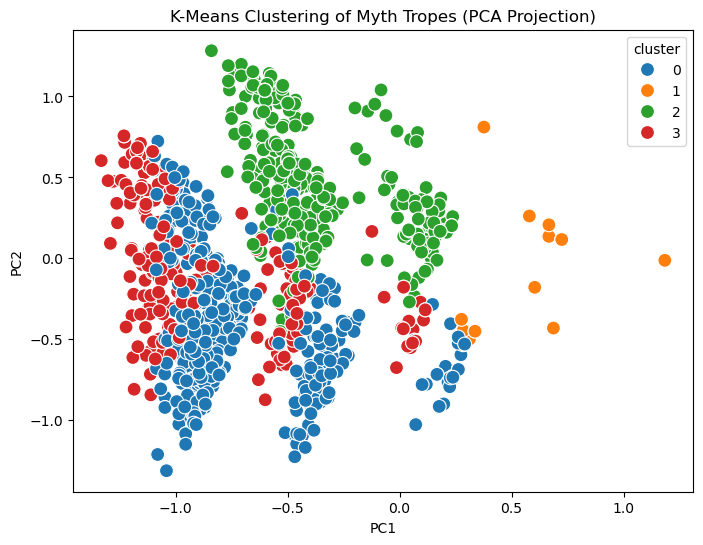

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_tropes.drop(columns='cluster'))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_tropes['cluster'], palette="tab10", s=100)
plt.title("K-Means Clustering of Myth Tropes (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
df_tropes['cluster'] = df['cluster']

# Group by cluster and sum up trope presence
cluster_tropes = df_tropes.groupby('cluster').sum()


top_tropes_0 = cluster_tropes.loc[0].sort_values(ascending=False).head(10)
top_tropes_1 = cluster_tropes.loc[1].sort_values(ascending=False).head(10)


print(df['cluster'].value_counts())

print("Top Tropes in Cluster 0 (blue):")
print(top_tropes_0)

print("\nTop Tropes in Cluster 1 (red):")
print(top_tropes_1)

cluster
1    794
0    609
2    528
3    344
Name: count, dtype: int64
Top Tropes in Cluster 0 (blue):
DragonsAreDivine    150
TheChosenOne        132
Trickster God       131
SpiritAdvisor       131
DealWithTheDevil    127
GodOfChaos          120
WhiteMage           118
Satan               118
DarkestHour         104
WarGod               90
Name: 0, dtype: int64

Top Tropes in Cluster 1 (red):
AnimalMotifs     794
BeastMan         791
Reincarnation    787
TheTrickster     780
MoonGod            2
NatureSpirit       2
GrimReaper         2
WhiteMage          2
AntiHero           1
BigBad             1
Name: 1, dtype: int64


In [40]:
top_tropes_2 = cluster_tropes.loc[2].sort_values(ascending=False).head(10)
top_tropes_3 = cluster_tropes.loc[3].sort_values(ascending=False).head(10)

print("Top Tropes in Cluster 2:")
print(top_tropes_2)

print("\nTop Tropes in Cluster 3:")
print(top_tropes_3)

Top Tropes in Cluster 2:
Reincarnation         528
DarkestHour           168
BigBad                140
TheChosenOne          113
GrimReaper             80
SpiritAdvisor          73
ProphecyTwist          64
FateWorseThanDeath     58
TheTrickster           56
DealWithTheDevil       54
Name: 2, dtype: int64

Top Tropes in Cluster 3:
BigBad              344
DarkestHour         100
DealWithTheDevil     76
SpiritAdvisor        76
AntiHero             66
TheTrickster         64
Trickster God        58
Satan                56
GodOfChaos           54
TheChosenOne         51
Name: 3, dtype: int64


In [27]:
theme_map = {
    0: "Divine Conflict & Deific Representation",     # Blue
    1: "Shapeshifters, Rebirth & Primal Archetypes",  # Red
    2: "Rebirth, Prophecy & Fate",                    # Green
    3: "Morally Grey: the Antihero’s Path"            # Orange
}

df['myth_theme'] = df['cluster'].map(theme_map)

In [28]:
#another approach to unsupervised learning: Agglomerative Clustering
# Drop cluster label if still in df_tropes
X_cluster = df_tropes.drop(columns='cluster', errors='ignore')

# Try different cluster counts
for k in range(2, 10):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    print(f"k={k} → silhouette score = {score:.4f}")


k=2 → silhouette score = 0.3549
k=3 → silhouette score = 0.3380
k=4 → silhouette score = 0.3445
k=5 → silhouette score = 0.3500
k=6 → silhouette score = 0.3533
k=7 → silhouette score = 0.3604
k=8 → silhouette score = 0.3645
k=9 → silhouette score = 0.3675


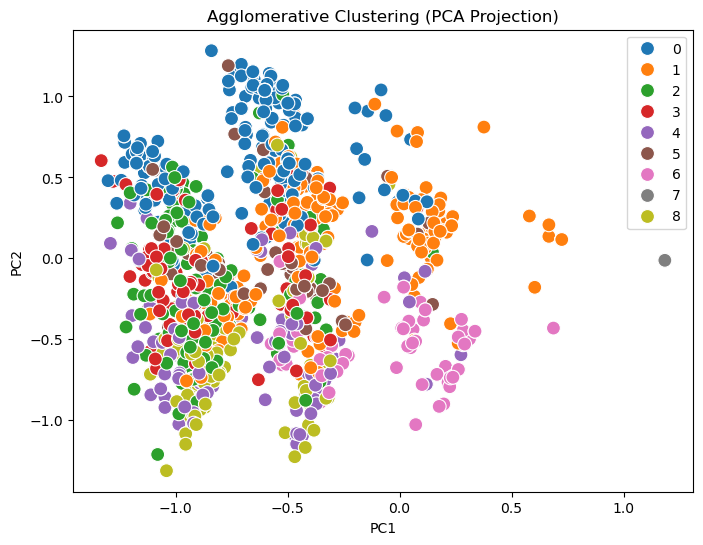

In [ ]:
pca_agg = PCA(n_components=2).fit_transform(X_cluster)
labels_agg = agg.fit_predict(X_cluster)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_agg[:, 0], y=pca_agg[:, 1], hue=labels_agg, palette="tab10", s=100)
plt.title("Agglomerative Clustering (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


df['agglo_cluster'] = labels_agg

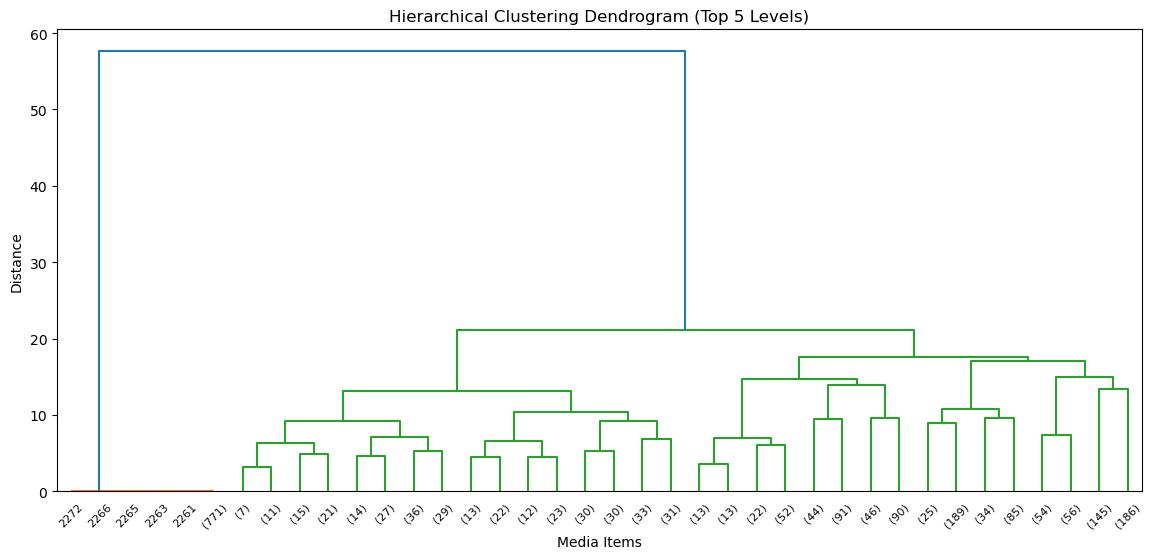

In [30]:
Z = linkage(X_cluster, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (Top 5 Levels)")
plt.xlabel("Media Items")
plt.ylabel("Distance")
plt.show()

In [31]:
#compare k-means and agglomerative clustering
pd.crosstab(df['cluster'], df['agglo_cluster'], rownames=['KMeans'], colnames=['Agglomerative'])

Agglomerative,0,1,2,3,4,5,6,7,8
KMeans,,,,,,,,,
0,32,112,130,88,66,26,46,0,109
1,0,11,0,0,0,0,7,776,0
2,233,204,16,16,19,19,0,0,21
3,89,6,40,41,51,65,47,0,5


In [32]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df['cluster'], df['agglo_cluster'])
print(f"Adjusted Rand Index: {ari:.4f}")

Adjusted Rand Index: 0.5657


In [36]:
export_cols = [
    'id', 'text', 'type', 'source', 'imdb_title', 'imdb_year',
    'imdb_genres', 'inferred_media_type', 'combined_text',
    'has_semantic_match', 'has_lexical_match', 'has_sentence_myth_trope_hit',
    'max_trope_similarity', 'myth_hit_count', 'myth_theme', 'cluster',
    'has_myth_hit', 'has_myth_trope_hit', 'agglo_cluster'
]

df[export_cols].to_json("../data/supervise_myth_clusters.json", orient="records", lines=True)